# VeriPromiseESG 2026 ESG 承諾驗證優化方案
## 5-Fold Stratified K-Fold 交叉驗證 & 多模型 Logits 平均集成 (Ensemble)

本 Notebook 為優化版本的範例程式。主要優化方向包含：
1. **5-Fold Stratified K-Fold 交叉驗證**：根據權重最高且最不均衡的目標欄位 `evidence_quality` 進行分層切分，以確保每一折訓練和驗證的資料分佈一致。
2. **Out-of-Fold (OOF) 評估**：合併 5 折的驗證預測結果，計算出最客觀且泛化能力最佳的 CV 分數。
3. **多模型 Logits 平均集成 (Ensemble)**：將 5 個 Folds 的最佳模型 Logits 平均作為最終 Ensemble 預測，進一步提升 F1 表現與穩定性。
4. **豐富的視覺化分析**：繪製 5 折各自的 Training Loss & Validation Score 曲線，並繪製 4 個任務的 Confusion Matrix。

## Step 1: 載入套件與環境設定

In [2]:
import json
import os
# os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")  # 優先使用目前較空的第二張 GPU
# os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")  # 讓 CUDA 錯誤在真正出事的那一行回報
import gc
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 設定中文字型與圖表顯示
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU 裝置名稱: {torch.cuda.get_device_name(0)}')

套件載入完成！
PyTorch 版本: 2.11.0+cu128
CUDA 可用: True
GPU 裝置名稱: NVIDIA GeForce RTX 5070


## Step 2: 設定超參數與標籤映射

In [3]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "bert-base-chinese"   # 或是 "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 256
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4  # 等效 batch size = 2 * 4 = 8，但單次 GPU 記憶體壓力小很多
EPOCHS = 5
LR = 2e-5
K_FOLDS = 5
FREEZE_BACKBONE = False             # 若 CUDA 不可用而使用 CPU 訓練，設為 True 能凍結 BERT 並加速訓練約 15 倍
USE_GRADIENT_CHECKPOINTING = True   # 降低 BERT 訓練時的 GPU 記憶體使用量
USE_CLASS_WEIGHTED_LOSS = True      # 針對少數類別提高 CrossEntropyLoss 權重
USE_MINORITY_OVERSAMPLING = True    # 只增強每個 fold 的訓練集，驗證集不動
OVERSAMPLE_FIELD = "evidence_quality"
MIN_CLASS_COUNT_RATIO = 0.30        # 少數類別至少補到 max_count 的 30%，但會受下面複製上限限制
MAX_DUPLICATES_PER_SAMPLE = 8       # 避免單一少數樣本被複製過多造成過擬合
STRATIFY_FIELD = "evidence_quality"  # 用來做 Stratified K-Fold 的欄位
RESULTS_DIR = "../results/2026-06-02_kfold_ensemble_weight_enhanced"  # 儲存結果的資料夾，建議包含日期和主要設定以便區分
os.makedirs(RESULTS_DIR, exist_ok=True)

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤與 ID 的對應
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'交叉驗證折數 (K): {K_FOLDS}')
print(f'分層依據欄位: {STRATIFY_FIELD}')

超參數設定完成！
使用模型: bert-base-chinese
交叉驗證折數 (K): 5
分層依據欄位: evidence_quality


## Step 3: 載入資料

優先讀取本地的 `data/vpesg_4k_train_1000.json`，若無則從 GitHub 下載。

In [4]:
import urllib.request

DATA_PATH = "../data/vpesg_4k_train_1000_enhance.json"

if not os.path.exists(DATA_PATH):
    # 如果本地 data/ 底下沒有，嘗試在目前目錄或下載
    if os.path.exists("vpesg4k_train_1000.json"):
        DATA_PATH = "vpesg4k_train_1000.json"
    else:
        print("本地找不到資料，開始從 GitHub 下載...")
        DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/refs/heads/main/vpesg4k_train_1000.json"
        urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
        DATA_PATH = "vpesg4k_train_1000.json"
        print("下載完成！")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    all_data = json.load(f)

print(f"資料載入成功！共 {len(all_data)} 筆資料。")

資料載入成功！共 1250 筆資料。


## Step 4: 建立 PyTorch Dataset 與 DataLoader

In [5]:
class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data']

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        labels = {}
        for field, mapping in self.label2id.items():
            label_text = sample[field]
            if label_text == '':
                label_text = 'N/A'
            labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

# 初始化 Tokenizer (採用通用 AutoTokenizer)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Step 5: 模型架構設計

使用 `AutoModel` 以獲得更好的預訓練模型相容性，並加入 Dropout 防止過擬合。

In [6]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels_dict, freeze_backbone=False, use_gradient_checkpointing=False):
        super().__init__()
        # 載入預訓練 Backbone 模型
        self.encoder = AutoModel.from_pretrained(model_name)
        if use_gradient_checkpointing and hasattr(self.encoder, "gradient_checkpointing_enable"):
            self.encoder.gradient_checkpointing_enable()
        hidden_size = self.encoder.config.hidden_size
        
        if freeze_backbone:
            for param in self.encoder.parameters():
                param.requires_grad = False
        
        # Dropout 層防止過擬合
        self.dropout = nn.Dropout(0.1)
        
        # 各預測任務的分類頭
        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # 採用 pooler_output ([CLS] 的表示向量)
        pooled = outputs.pooler_output
        pooled = self.dropout(pooled)

        logits = {
            field: clf(pooled)
            for field, clf in self.classifiers.items()
        }
        return logits

## Step 6: 定義訓練、評估與預測函數

In [7]:
def normalize_label(label_text):
    return "N/A" if label_text == "" else label_text

def compute_class_weights(data, label2id, device):
    class_weights = {}
    for field, mapping in label2id.items():
        counts = Counter(normalize_label(sample[field]) for sample in data)
        total_samples = sum(counts.values())
        num_classes = len(mapping)
        weights = torch.ones(num_classes, dtype=torch.float)
        for label, class_id in mapping.items():
            class_count = counts.get(label, 0)
            if class_count > 0:
                weights[class_id] = total_samples / (num_classes * class_count)
                #feat 
        class_weights[field] = weights.to(device)
    return class_weights

def make_criteria(class_weights):
    return {
        field: nn.CrossEntropyLoss(weight=class_weights[field])
        for field in EVAL_FIELDS
    }

def oversample_minority_classes(data, field, min_class_count_ratio=0.30, max_duplicates_per_sample=8):
    grouped = {label: [] for label in EVAL_FIELDS[field]}
    for sample in data:
        grouped[normalize_label(sample[field])].append(sample)

    max_count = max(len(samples) for samples in grouped.values())
    target_count = max(1, int(max_count * min_class_count_ratio))
    augmented = list(data)
    added_by_label = {}

    for label, samples in grouped.items():
        if not samples or len(samples) >= target_count:
            added_by_label[label] = 0
            continue
        max_add = len(samples) * max_duplicates_per_sample
        add_count = min(target_count - len(samples), max_add)
        for i in range(add_count):
            augmented.append(dict(samples[i % len(samples)]))
        added_by_label[label] = add_count

    return augmented, added_by_label

def train_one_epoch(model, dataloader, optimizer, scheduler, device, criteria):
    model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)

        losses = []
        for field in EVAL_FIELDS:
            target_cpu = batch["labels"][field]
            min_label = target_cpu.min().item()
            max_label = target_cpu.max().item()
            num_class = logits[field].size(-1)
            if logits[field].dim() != 2 or logits[field].size(0) != target_cpu.size(0):
                raise ValueError(
                    f"{field}: logits shape {tuple(logits[field].shape)} 與 target shape {tuple(target_cpu.shape)} 不相容"
                )
            if min_label < 0 or max_label >= num_class:
                raise ValueError(
                    f"{field}: label id 超出範圍 [{min_label}, {max_label}], num_classes={num_class}"
                )
            losses.append(criteria[field](logits[field], target_cpu.to(device)))

        loss = sum(losses) / GRADIENT_ACCUMULATION_STEPS

        loss.backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
    return total_loss / len(dataloader)

def evaluate_hybrid(gt_data, pred_data):
    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results

def predict(model, dataloader, device, id2label):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)
    return predictions

## Step 7: 5-Fold Stratified K-Fold 交叉驗證訓練迴圈

我們將依據 `evidence_quality` 欄位進行 Stratified K-Fold 切分。對於每一折：
- 訓練模型並評估
- 儲存該折最佳模型至 `results/2026-05-31_kfold_ensemble/best_model_fold_{fold}.pt`
- 收集該折在驗證集上的 Out-of-Fold (OOF) 預測，用於計算整體交叉驗證指標。

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 提取用來做分層的標籤
stratify_labels = [sample[STRATIFY_FIELD] for sample in all_data]

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# 紀錄每折的訓練歷史
fold_histories = []
# 儲存所有折的驗證集預測結果 (OOF 預測)，初始化長度為總樣本數的 placeholder
oof_predictions = [None] * len(all_data)

for fold, (train_idx, val_idx) in enumerate(skf.split(all_data, stratify_labels)):
    print(f"\n========== Fold {fold + 1} / {K_FOLDS} ==========")
    
    # 建立該折的 Dataset 與 DataLoader
    fold_train_data = [all_data[i] for i in train_idx]
    fold_val_data = [all_data[i] for i in val_idx]

    if USE_MINORITY_OVERSAMPLING:
        fold_train_data, added_by_label = oversample_minority_classes(
            fold_train_data,
            OVERSAMPLE_FIELD,
            min_class_count_ratio=MIN_CLASS_COUNT_RATIO,
            max_duplicates_per_sample=MAX_DUPLICATES_PER_SAMPLE,
        )
        print(f"Oversampling {OVERSAMPLE_FIELD}: {added_by_label} | train size = {len(fold_train_data)}")
    
    train_dataset = ESGDataset(fold_train_data, tokenizer, label2id)
    val_dataset = ESGDataset(fold_val_data, tokenizer, label2id)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    
    if device.type == "cuda":
        torch.cuda.empty_cache()

    class_weights = compute_class_weights(fold_train_data, label2id, device)
    criteria = make_criteria(class_weights) if USE_CLASS_WEIGHTED_LOSS else {
        field: nn.CrossEntropyLoss() for field in EVAL_FIELDS
    }
    if USE_CLASS_WEIGHTED_LOSS:
        for field, weights in class_weights.items():
            weight_text = ", ".join(
                f"{id2label[field][i]}={weights[i].detach().cpu().item():.3f}"
                for i in range(len(weights))
            )
            print(f"Class weights [{field}]: {weight_text}")

    # 重新初始化模型、優化器與學習率排程器
    model = MultiTaskModel(
        MODEL_NAME,
        num_labels,
        freeze_backbone=FREEZE_BACKBONE,
        use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING,
    ).to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    
    total_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    best_score = 0.0
    history = {"train_loss": [], "val_score": []}
    
    MODEL_SAVE_PATH = os.path.join(RESULTS_DIR, f"best_model_fold_{fold}.pt")
    
    for epoch in range(EPOCHS):
        avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, criteria)
        history["train_loss"].append(avg_loss)
        
        # 驗證集預測
        val_preds = predict(model, val_loader, device, id2label)
        val_results = evaluate_hybrid(fold_val_data, val_preds)
        current_score = val_results["final_weighted_score"]
        history["val_score"].append(current_score)
        
        print(f"  Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_loss:.4f} | Val Weighted F1: {current_score:.5f}")
        
        # 儲存該折最佳模型
        if current_score > best_score:
            best_score = current_score
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            # 暫存該折最佳模型在驗證集上的預測結果
            best_val_preds = val_preds
            print(f"    --> 發現更佳模型！已儲存。")
            
    fold_histories.append(history)
    
    # 將該折的最佳預測結果填入 OOF 對應的索引中
    for idx, val_pos in enumerate(val_idx):
        oof_predictions[val_pos] = best_val_preds[idx]

    del model, optimizer, scheduler, train_loader, val_loader, train_dataset, val_dataset, criteria, class_weights
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
        
print("\n5-Fold 交叉驗證訓練完成！所有模型權重已儲存。")

使用設備: cuda

========== Fold 1 / 5 ==========
Oversampling evidence_quality: {'Clear': 0, 'Not Clear': 35, 'Misleading': 46, 'N/A': 0} | train size = 1081
Class weights [promise_status]: Yes=0.579, No=3.677
Class weights [verification_timeline]: already=0.643, within_2_years=2.079, between_2_and_5_years=0.751, more_than_5_years=1.050, N/A=1.471
Class weights [evidence_status]: Yes=0.443, No=2.978, N/A=2.451
Class weights [evidence_quality]: Clear=0.531, Not Clear=1.778, Misleading=1.778, N/A=1.008


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4833.07it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  Epoch 1/5 | Train Loss: 4.3349 | Val Weighted F1: 0.35176
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2653 | Val Weighted F1: 0.45474
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.2561 | Val Weighted F1: 0.47744
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.6463 | Val Weighted F1: 0.48894
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.3302 | Val Weighted F1: 0.48893

========== Fold 2 / 5 ==========
Oversampling evidence_quality: {'Clear': 0, 'Not Clear': 36, 'Misleading': 46, 'N/A': 0} | train size = 1082
Class weights [promise_status]: Yes=0.580, No=3.631
Class weights [verification_timeline]: already=0.625, within_2_years=2.208, between_2_and_5_years=0.741, more_than_5_years=1.098, N/A=1.452
Class weights [evidence_status]: Yes=0.444, No=3.006, N/A=2.421
Class weights [evidence_quality]: Clear=0.531, Not Clear=1.780, Misleading=1.780, N/A=1.006


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6960.48it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.4221 | Val Weighted F1: 0.32499
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.4047 | Val Weighted F1: 0.44188
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4789 | Val Weighted F1: 0.43946
  Epoch 4/5 | Train Loss: 1.8012 | Val Weighted F1: 0.49476
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4359 | Val Weighted F1: 0.46464

========== Fold 3 / 5 ==========
Oversampling evidence_quality: {'Clear': 0, 'Not Clear': 35, 'Misleading': 46, 'N/A': 0} | train size = 1081
Class weights [promise_status]: Yes=0.581, No=3.603
Class weights [verification_timeline]: already=0.682, within_2_years=1.832, between_2_and_5_years=0.730, more_than_5_years=1.081, N/A=1.441
Class weights [evidence_status]: Yes=0.444, No=3.028, N/A=2.402
Class weights [evidence_quality]: Clear=0.532, Not Clear=1.778, Misleading=1.778, N/A=1.005


...

  Epoch 1/5 | Train Loss: 4.2915 | Val Weighted F1: 0.36745
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.3019 | Val Weighted F1: 0.47237
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4059 | Val Weighted F1: 0.49430
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.7063 | Val Weighted F1: 0.51934
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.3810 | Val Weighted F1: 0.51172

========== Fold 4 / 5 ==========
Oversampling evidence_quality: {'Clear': 0, 'Not Clear': 35, 'Misleading': 47, 'N/A': 0} | train size = 1082
Class weights [promise_status]: Yes=0.581, No=3.583
Class weights [verification_timeline]: already=0.598, within_2_years=2.042, between_2_and_5_years=0.790, more_than_5_years=1.145, N/A=1.433
Class weights [evidence_status]: Yes=0.444, No=3.056, N/A=2.389
Class weights [evidence_quality]: Clear=0.531, Not Clear=1.780, Misleading=1.780, N/A=1.006


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7779.03it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.2525 | Val Weighted F1: 0.40632
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2779 | Val Weighted F1: 0.48641
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4274 | Val Weighted F1: 0.50147
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.8305 | Val Weighted F1: 0.50773
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.5093 | Val Weighted F1: 0.48838

========== Fold 5 / 5 ==========
Oversampling evidence_quality: {'Clear': 0, 'Not Clear': 35, 'Misleading': 47, 'N/A': 0} | train size = 1082
Class weights [promise_status]: Yes=0.579, No=3.680
Class weights [verification_timeline]: already=0.638, within_2_years=1.967, between_2_and_5_years=0.767, more_than_5_years=1.061, N/A=1.472
Class weights [evidence_status]: Yes=0.444, No=2.956, N/A=2.454
Class weights [evidence_quality]: Clear=0.531, Not Clear=1.780, Misleading=1.780, N/A=1.006


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7024.93it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.2369 | Val Weighted F1: 0.37831
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2868 | Val Weighted F1: 0.46770
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4446 | Val Weighted F1: 0.50559
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.8088 | Val Weighted F1: 0.51606
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4346 | Val Weighted F1: 0.52653
    --> 發現更佳模型！已儲存。

5-Fold 交叉驗證訓練完成！所有模型權重已儲存。


## Step 8: 繪製訓練折線圖

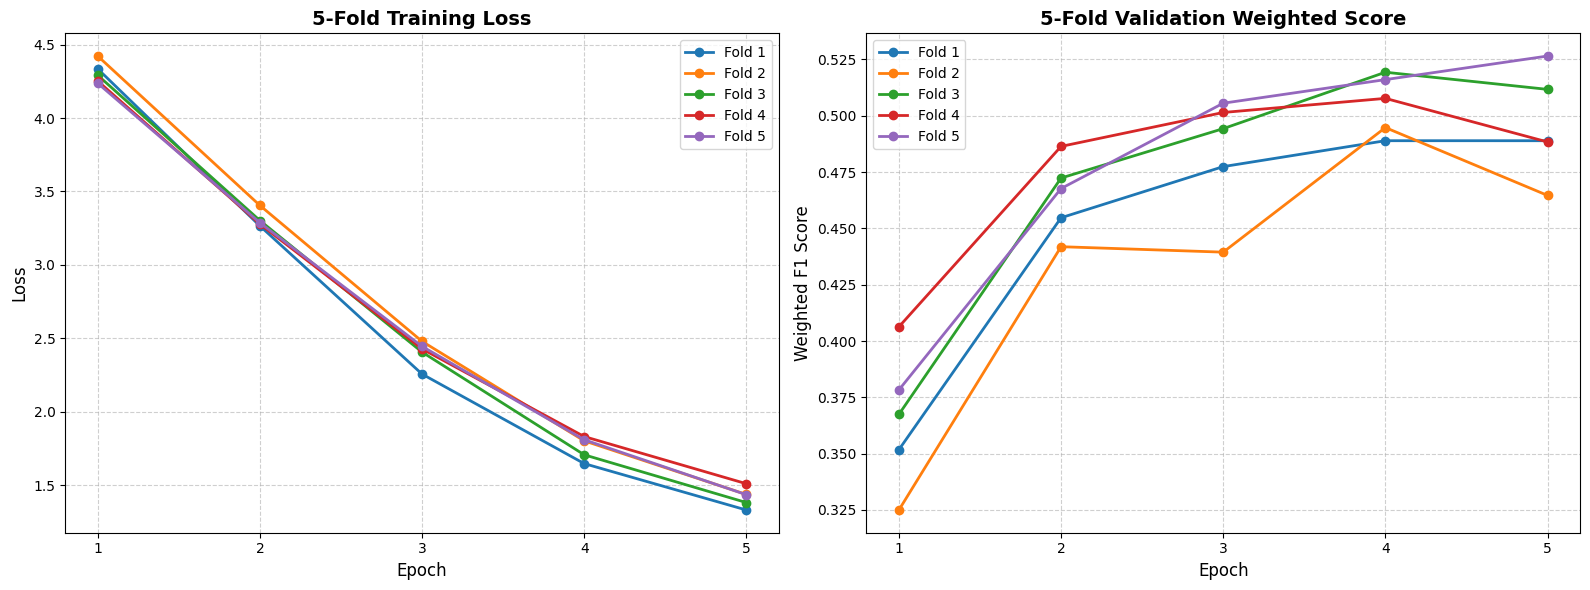

折線圖已儲存至: ../results/2026-06-02_kfold_ensemble_weight_enhanced\training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, EPOCHS + 1)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. 繪製每一折的 Training Loss
for fold in range(K_FOLDS):
    axes[0].plot(epochs_range, fold_histories[fold]["train_loss"], 
                 '-o', label=f'Fold {fold+1}', color=colors[fold], linewidth=2)
axes[0].set_title("5-Fold Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_xticks(epochs_range)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# 2. 繪製每一折的 Validation Weighted Score
for fold in range(K_FOLDS):
    axes[1].plot(epochs_range, fold_histories[fold]["val_score"], 
                 '-o', label=f'Fold {fold+1}', color=colors[fold], linewidth=2)
axes[1].set_title("5-Fold Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Weighted F1 Score", fontsize=12)
axes[1].set_xticks(epochs_range)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"折線圖已儲存至: {os.path.join(RESULTS_DIR, 'training_curves.png')}")

## Step 9: 實作 Ensemble (多模型 Logits 平均集成) 預測

我們將實作一個預測函數，讀入 5 折的所有模型，並將 5 個模型對同一筆輸入產生的 Logits 進行平均，再取最高分作為預測結果。這通常能大幅增強泛化能力並提升 F1 分數。

In [10]:
def predict_ensemble(models, dataloader, device, id2label):
    """
    使用多模型 Logits 平均的 Ensemble 預測函數
    """
    for m in models:
        m.eval()
        
    ensemble_predictions = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            # 累加所有模型的 Logits
            batch_logits = {field: [] for field in EVAL_FIELDS}
            for model in models:
                logits = model(input_ids, attention_mask)
                for field in EVAL_FIELDS:
                    batch_logits[field].append(logits[field])
            
            # 計算平均 Logits
            avg_logits = {}
            for field in EVAL_FIELDS:
                # 堆疊後取 mean，shape: [batch_size, num_classes]
                avg_logits[field] = torch.stack(batch_logits[field]).mean(dim=0)
                
            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    pred_id = avg_logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                ensemble_predictions.append(pred)
                
    return ensemble_predictions

## Step 10: 載入最佳模型進行預測評估

In [11]:
# 載入 5 個 Fold 的最佳模型權重
models = []
for fold in range(K_FOLDS):
    m = MultiTaskModel(MODEL_NAME, num_labels, freeze_backbone=FREEZE_BACKBONE).to(device)
    MODEL_SAVE_PATH = os.path.join(RESULTS_DIR, f"best_model_fold_{fold}.pt")
    m.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    models.append(m)
print(f"成功載入 {len(models)} 個 Fold 的最佳模型權重！")

# 建立完整的資料載入器 (不打亂)
full_dataset = ESGDataset(all_data, tokenizer, label2id)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 1. 評估 Out-of-Fold (OOF) 分數 (最客觀的 Cross-Validation 分數)
oof_results = evaluate_hybrid(all_data, oof_predictions)

# 2. 評估 5-Model Ensemble 預測分數 (訓練集上的集成預測結果)
ensemble_preds = predict_ensemble(models, full_loader, device, id2label)
ensemble_results = evaluate_hybrid(all_data, ensemble_preds)

print("\n" + "=" * 60)
print(f"【1】Out-of-Fold (OOF) 交叉驗證加權分數: {oof_results['final_weighted_score']:.5f}")
print(f"【2】5-Model Ensemble 集成加權分數: {ensemble_results['final_weighted_score']:.5f}")
print("=" * 60)

print("\n--- OOF 各欄位詳細指標 ---")
for field in EVAL_FIELDS:
    r = oof_results[field]
    print(f"  {field} (w={r['weight']}): Macro F1 = {r['macro_f1']:.4f} | Micro F1 = {r['micro_f1']:.4f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6650.46it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6646.97it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 

成功載入 5 個 Fold 的最佳模型權重！

【1】Out-of-Fold (OOF) 交叉驗證加權分數: 0.51154
【2】5-Model Ensemble 集成加權分數: 0.67786

--- OOF 各欄位詳細指標 ---
  promise_status (w=0.2): Macro F1 = 0.7939 | Micro F1 = 0.9048
  verification_timeline (w=0.15): Macro F1 = 0.4970 | Micro F1 = 0.5540
  evidence_status (w=0.3): Macro F1 = 0.4529 | Micro F1 = 0.7787
  evidence_quality (w=0.35): Macro F1 = 0.4067 | Micro F1 = 0.5878


## Step 11: 繪製混淆矩陣 (Confusion Matrix)

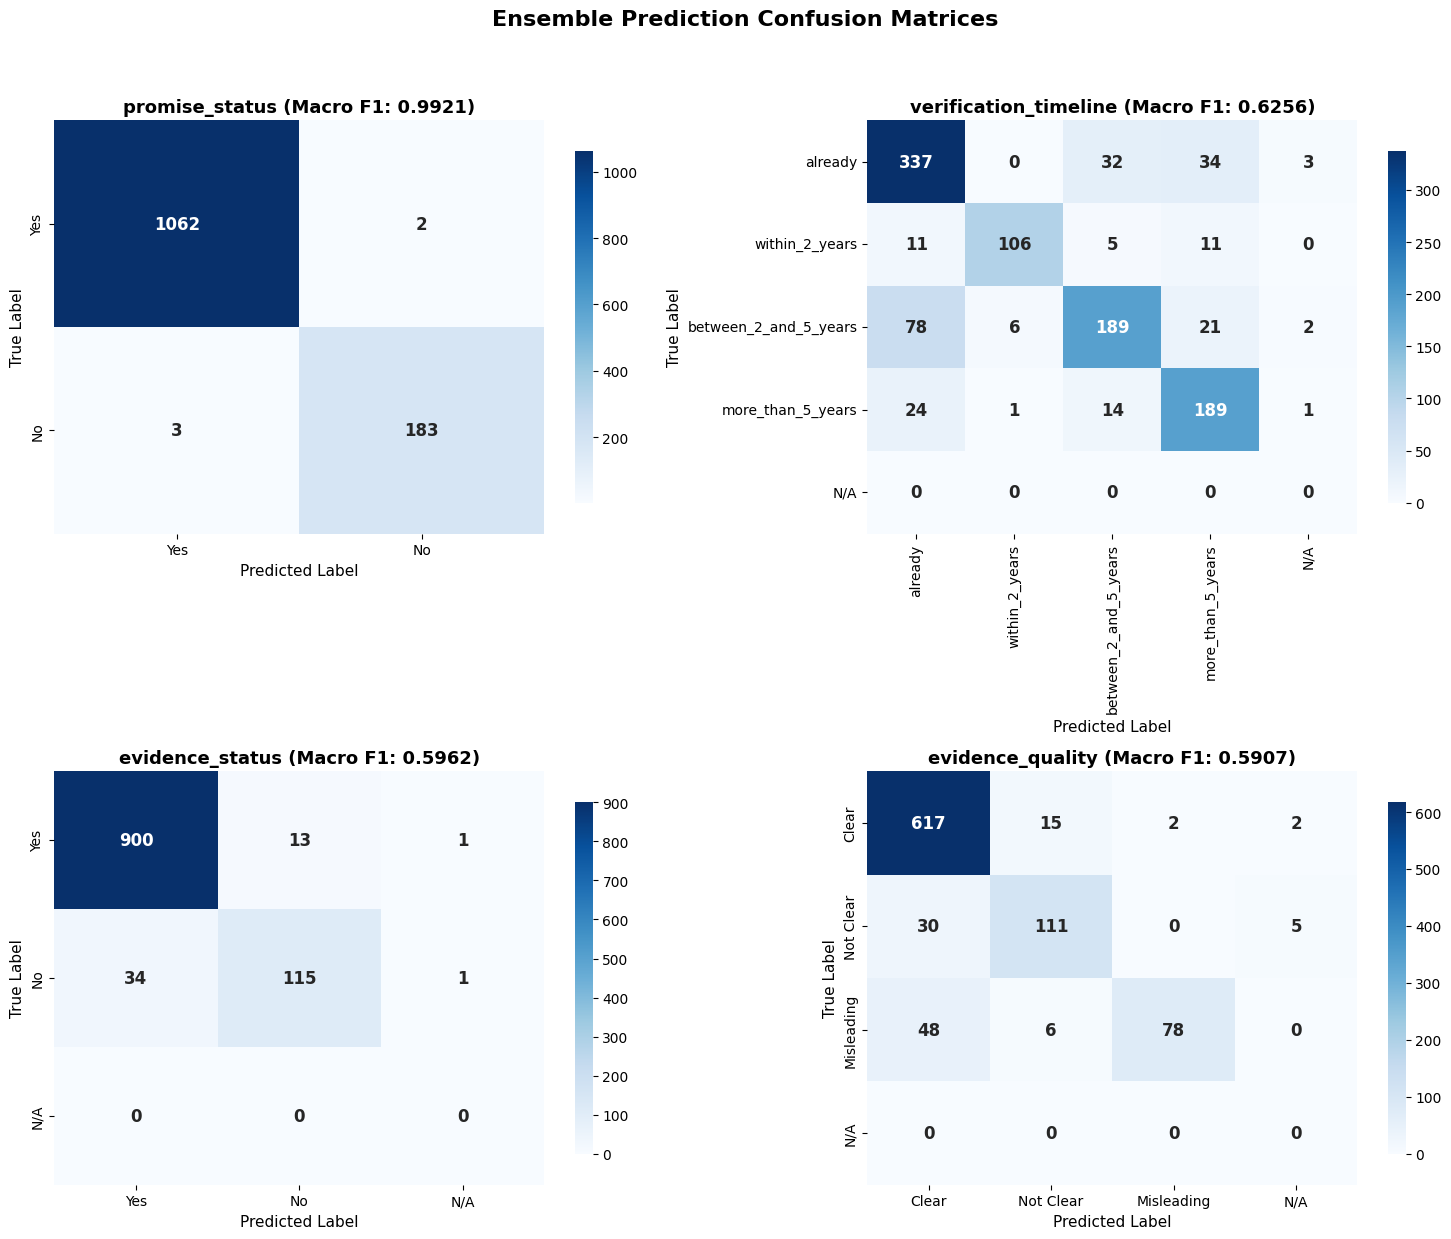

混淆矩陣熱力圖已儲存至: ../results/2026-06-02_kfold_ensemble_weight_enhanced\confusion_matrices.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.suptitle("Ensemble Prediction Confusion Matrices", fontsize=16, fontweight='bold', y=0.95)

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]
    
    y_true = [item[field] for item in all_data]
    y_pred = [item[field] for item in ensemble_preds]
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # 繪製 Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, 
                annot_kws={'size': 12, 'weight': 'bold'},
                cbar_kws={'shrink': 0.85})
    
    # 加註標籤與標題
    ax.set_title(f"{field} (Macro F1: {ensemble_results[field]['macro_f1']:.4f})", fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"混淆矩陣熱力圖已儲存至: {os.path.join(RESULTS_DIR, 'confusion_matrices.png')}")

## Step 12: 儲存評估結果與超參數設定

In [13]:
# 1. 儲存 config.json
config_data = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "epochs_per_fold": EPOCHS,
    "use_class_weighted_loss": USE_CLASS_WEIGHTED_LOSS,
    "use_minority_oversampling": USE_MINORITY_OVERSAMPLING,
    "oversample_field": OVERSAMPLE_FIELD,
    "min_class_count_ratio": MIN_CLASS_COUNT_RATIO,
    "max_duplicates_per_sample": MAX_DUPLICATES_PER_SAMPLE,
    "learning_rate": LR,
    "k_folds": K_FOLDS,
    "stratify_by_field": STRATIFY_FIELD
}
config_path = os.path.join(RESULTS_DIR, "config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_data, f, ensure_ascii=False, indent=2)
print(f"✅ 超參數已寫入: {config_path}")

# 2. 儲存 metrics.json (儲存 Ensemble 與 OOF 交叉驗證分數)
metrics_data = {
    "oof_weighted_f1": oof_results["final_weighted_score"],
    "ensemble_weighted_f1": ensemble_results["final_weighted_score"],
    "oof_detailed": {
        field: {
            "macro_f1": oof_results[field]["macro_f1"],
            "micro_f1": oof_results[field]["micro_f1"]
        } for field in EVAL_FIELDS
    },
    "ensemble_detailed": {
        field: {
            "macro_f1": ensemble_results[field]["macro_f1"],
            "micro_f1": ensemble_results[field]["micro_f1"]
        } for field in EVAL_FIELDS
    }
}
metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, ensure_ascii=False, indent=2)
print(f"✅ 評估指標已寫入: {metrics_path}")

# 3. 儲存 prediction.json (包含 Ensemble 預測標籤)
output_data = []
for orig, pred in zip(all_data, ensemble_preds):
    item = dict(orig)
    item.update(pred)
    output_data.append(item)

prediction_path = os.path.join(RESULTS_DIR, "prediction.json")
with open(prediction_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)
print(f"✅ 最終預測數據已寫入: {prediction_path}")

✅ 超參數已寫入: ../results/2026-06-02_kfold_ensemble_weight_enhanced\config.json
✅ 評估指標已寫入: ../results/2026-06-02_kfold_ensemble_weight_enhanced\metrics.json
✅ 最終預測數據已寫入: ../results/2026-06-02_kfold_ensemble_weight_enhanced\prediction.json
